# Met Office Datasets - Radar Observations

The UK Weather Radar Network is designed to provide continuous, real-time rainfall data over almost the whole of the UK land area and inshore waters. The data can provide valuable information for immediate emergency response in times of extreme weather conditions, as well as providing data to flood planners when managing future risk. In addition to rainfall data the radar network provides observations for the Met Office numerical weather prediction system, in the form of Doppler measurements of wind and a novel technique for using radars to measure of changes in humidity.

Further info
* [Met Office Radar Systems](https://www.metoffice.gov.uk/research/weather/observations-research/radar-systems)

Radar data can be accessed in a variety of ways:
* * [Map of latest radar observations](https://weather.metoffice.gov.uk/maps-and-charts/rainfall-radar-forecast-map#?layer=rainfall-rate)
  * [CEDA Catalog](https://catalogue.ceda.ac.uk/uuid/82adec1f896af6169112d09cc1174499/)
  * [AWS Sustainable Data Initiative](https://registry.opendata.aws/met-office-uk-radar-observations/)

Today we'll be using the [snapshot](https://github.com/mlcast-community/mlcast-datasets) that has been prepared for use in an ML workflow by the MLcast community.

In [2]:
import pathlib
import datetime

In [3]:
import xarray

In [4]:
xarray.__version__

'2026.7.0'

## Load data subset
In this activity we are going to look at data from the Met Office radar data that has been prepared in an **ML-ready** format as part of the MLCast community.

The data has been extracted and cached locally in the [data prep notebook](dscop_data_prep_uk_radar.ipynb). We have extracted 2 years of data.

Further reading 
* [MLCast Datasets repo](https://github.com/mlcast-community/mlcast-datasets)
* [Intake Catalog docs](https://intake.readthedocs.io/en/latest/catalog.html)
* [Zarr docs](https://zarr.readthedocs.io/en/stable/)

### Load the local subset

In [10]:
radar_dir = pathlib.Path('/data/users/stephen.haddad/uk_radar/')

In [22]:
radar_file_list = [f1 for f1 in radar_dir.iterdir() if f1.suffix == '.nc']
radar_file_list

[PosixPath('/data/users/stephen.haddad/uk_radar/uk_radar_20240616.nc'),
 PosixPath('/data/users/stephen.haddad/uk_radar/uk_radar_20240716.nc'),
 PosixPath('/data/users/stephen.haddad/uk_radar/uk_radar_20240619.nc'),
 PosixPath('/data/users/stephen.haddad/uk_radar/uk_radar_20240725.nc'),
 PosixPath('/data/users/stephen.haddad/uk_radar/uk_radar_20240617.nc'),
 PosixPath('/data/users/stephen.haddad/uk_radar/uk_radar_20240620.nc'),
 PosixPath('/data/users/stephen.haddad/uk_radar/uk_radar_20240710.nc'),
 PosixPath('/data/users/stephen.haddad/uk_radar/uk_radar_20240612.nc'),
 PosixPath('/data/users/stephen.haddad/uk_radar/uk_radar_20240629.nc'),
 PosixPath('/data/users/stephen.haddad/uk_radar/uk_radar_20240731.nc'),
 PosixPath('/data/users/stephen.haddad/uk_radar/uk_radar_20240605.nc'),
 PosixPath('/data/users/stephen.haddad/uk_radar/uk_radar_20240722.nc'),
 PosixPath('/data/users/stephen.haddad/uk_radar/uk_radar_20240712.nc'),
 PosixPath('/data/users/stephen.haddad/uk_radar/uk_radar_2024072

In [23]:
uk_radar_ds = xarray.open_mfdataset(radar_file_list)
uk_radar_ds

/var/tmp/ipykernel_2369856/387391273.py:1: FutureWarning: In a future version of xarray the default value for data_vars will change from data_vars='all' to data_vars=None. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set data_vars explicitly.
  uk_radar_ds = xarray.open_mfdataset(radar_file_list)


<xarray.Dataset> Size: 264GB
Dimensions:        (time: 17618, y: 2175, x: 1725, missing_times: 100404)
Coordinates:
  * time           (time) datetime64[ns] 141kB 2024-06-01 ... 2024-08-01
  * y              (y) float64 17kB 1.55e+06 1.548e+06 ... -6.235e+05 -6.245e+05
  * x              (x) float64 14kB -4.045e+05 -4.035e+05 ... 1.318e+06 1.32e+06
    lat            (y, x) float64 30MB dask.array<chunksize=(2175, 1725), meta=np.ndarray>
    lon            (y, x) float64 30MB dask.array<chunksize=(2175, 1725), meta=np.ndarray>
  * missing_times  (missing_times) datetime64[ns] 803kB 2005-07-05T06:40:00 ....
Data variables:
    crs            (time) float32 70kB nan nan nan nan nan ... nan nan nan nan
    RR             (time, y, x) float32 264GB dask.array<chunksize=(289, 2175, 1725), meta=np.ndarray>
Attributes:
    title:                      UK Met Office C-band rain radar 1 km composite
    license:                    OGL-UK-3.0
    history:                    Created at 2026-02-16T22:33:20+01:00
    mlcast_created_on:          2026-02-16T22:33:20+01:00
    mlcast_created_by:          Gabriele Franch <franch@fbk.eu>
    mlcast_created_with:        https://github.com/mlcast-community/mlcast-da...
    mlcast_dataset_version:     0.1.0
    mlcast_dataset_identifier:  UK-METOFFICE-RADAR
    consistent_timestep_start:  2005-07-05T00:00
    base_frequencies:           5min:2005-07-05T00:00/None

In [25]:
12*24*61

17568

(array([1.16932e+06, 7.70000e+01, 1.30000e+01, 7.00000e+00, 4.00000e+00,
        2.00000e+00, 0.00000e+00, 1.00000e+00, 0.00000e+00, 1.00000e+00]),
 array([  0.        ,  20.26874924,  40.53749847,  60.80624771,
         81.07499695, 101.34375   , 121.61249542, 141.88124084,
        162.1499939 , 182.41874695, 202.6875    ]),
 <BarContainer object of 10 artists>)

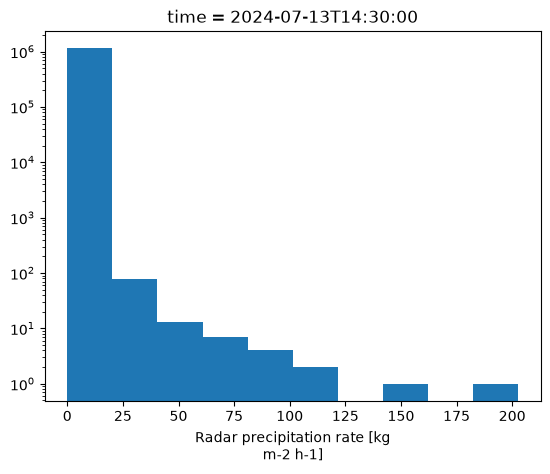

In [30]:
uk_radar_ds.sel(time=datetime.datetime(2024,7,13,14,30))['RR'].plot.hist(log=True)

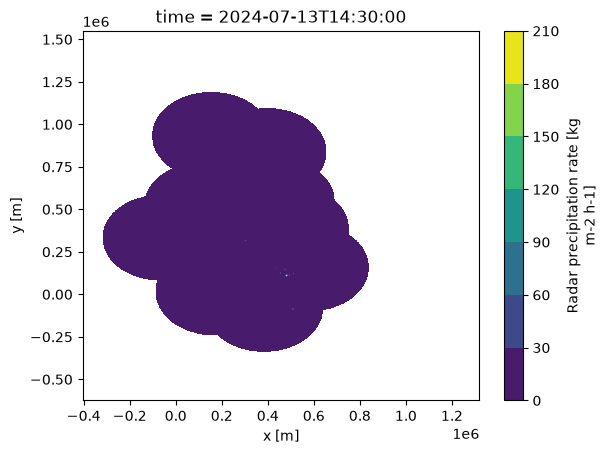

In [20]:
uk_radar_ds.sel(time=datetime.datetime(2024,7,13,14,30))['RR'].plot.contourf()

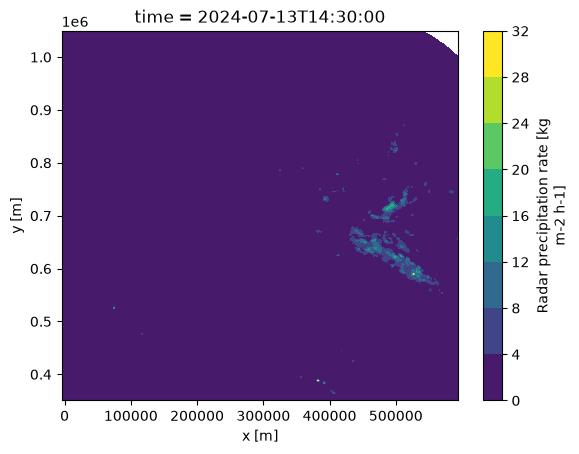

In [59]:
uk_radar_ds.sel(time=datetime.datetime(2024,7,13,14,30))['RR'][500:1200,400:1000].plot.contourf()

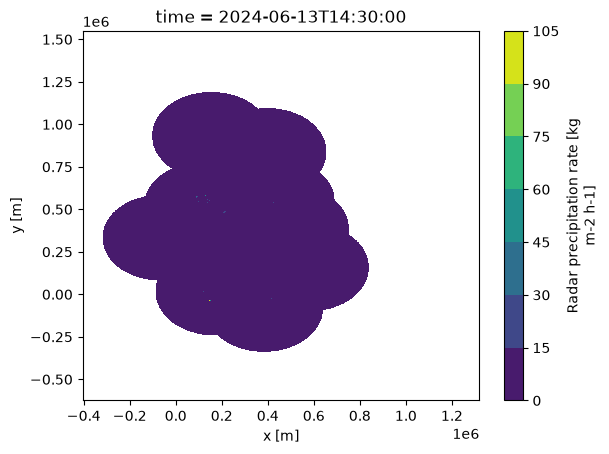

In [32]:
uk_radar_ds.sel(time=datetime.datetime(2024,6,13,14,30))['RR'].plot.contourf()